# Settings

In [1]:
options(scipen=999)
pacman::p_load(dplyr, stringr, data.table, tidyr, plyr,
               colorRamps, gridExtra, ggplot2, ggrepel, ggforce, ggalluvial,viridis,
               ggsankey, ggh4x)

## Directories

In [2]:
# Set working directories
base.dir =  "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/"
assets.dir = paste(base.dir, "Assets/", sep = "") 
results.dir = paste(base.dir, "Results/corrected/", sep = "")
permutation.result.dir = paste(base.dir, "Results/corrected.permutation.test/", sep = "")


# Databases
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

permutations.test.tmp.dir = paste(permutation.result.dir, "TMP/", sep = "")
permutations.test.res.dir = paste(permutation.result.dir, "Results/", sep = "")

cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

## Variables

In [3]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

# Contrasts
Contrast_1 = c(condition.ls[2], condition.ls[3], condition.ls[4])
Contrast_2 = c(condition.ls[1], condition.ls[1], condition.ls[1])

# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

Cellpop.compartment = as.data.frame(cbind(cell.pop.order, compartment))
Cellpop.compartment$compartment = factor(Cellpop.compartment$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
colnames(Cellpop.compartment)[1] = "Celltype"

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

Cellpop.compartment$colors.compartments = compartment
Cellpop.compartment$colors.compartments = mapvalues(Cellpop.compartment$colors.compartments, names(colors.compartments), colors.compartments, warn_missing = TRUE)
gaps.compartments = c(3, 9, 11, 12)

In [4]:
# Load and prepare Gaulton DB
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V3.txt"
# Load list of ligands and receptors
SM.ls.df = read.table(paste(assets.dir, "SM.ls.df.txt", sep=""), sep = "\t", stringsAsFactors = F, header = T)
SM.ls = unique(SM.ls.df$gene)
length(SM.ls)

# Load database
cc.db.data = read.table(cc.db, sep = "\t", stringsAsFactors = F, header = T)
# cc.db.data = cc.db.data[,c(11,2,3)]
message("CCDB number of interactions: ", length(levels(factor(cc.db.data$interaction_name))))

gaulton.db.data = read.table(Gaulton.db.dir, sep = "\t", stringsAsFactors = F, header = T)
colnames(gaulton.db.data)[1] = "gene"

SM.ls.df.GDB = merge(SM.ls.df, gaulton.db.data, by = "gene", all.x = TRUE)
SM.ls.df.GDB[is.na(SM.ls.df.GDB)] <- ""

# Calculate category sizes
categories.size = SM.ls.df.GDB[SM.ls.df.GDB$Type == "Ligand",]

# Ligands
ligands.GDB = filter(SM.ls.df.GDB, Type != "Receptor")
colnames(ligands.GDB)[1] = "ligand"
head(ligands.GDB)

[1] 857

CCDB number of interactions: 1939



,ligand,Type,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family
2,ADGRE5,Ligand,Cell-Cell Contact,CAM,Other_CAM,Other Cell Adhesion Proteins,-
3,ADIPOQ,Ligand,Secreted Signaling,Growth Factors & Cytokines,Other Cytokines,Other Cytokines,Adipokine Family
4,ADM,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone,Hormone (Heart),Adrenomedullin Family
5,AGRN,Ligand,ECM-Receptor,ECM,Other_ECM,Other ECM proteins,Agrin Family
6,AGT,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone,Hormone (Liver),Angiotensinogen Family


# Permutation test

## Observations

In [5]:
LR.data.consensus.sig.thresh = read.table(paste(results.dir,
                                               "LR.data.consensus.sig.thresh.txt", sep = ""),
                                          sep = "\t", stringsAsFactors = F, header = T)
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$target %in% cell.pop.order, ]
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$source %in% cell.pop.order, ]

In [6]:
# Split LR pairs
LR.data.ND = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[1], ]
LR.data.AAB = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[2], ]
LR.data.ETD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[3], ]
LR.data.LTD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[4], ]
nrow(LR.data.consensus.sig.thresh)
# Print stats
message("LR pairs in ND: ", nrow(LR.data.ND))
message("LR pairs in AAB : ", nrow(LR.data.AAB))
message("LR pairs in Early T1D: ", nrow(LR.data.ETD))
message("LR pairs in Late T1D: ", nrow(LR.data.LTD))

[1] 87650

LR pairs in ND: 27139

LR pairs in AAB : 27459

LR pairs in Early T1D: 18179

LR pairs in Late T1D: 14873



In [7]:
head(LR.data.consensus.sig.thresh, n=1)

,ligand,source,target,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,⋯,FDR,interaction.id,compartment.source,compartment.target,Type,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,ADCYAP1R1,0.00006164112,0.0001,ADCYAP1_ADCYAP1R1,ADCYAP1 - ADCYAP1R1,PACAP,Secreted Signaling,⋯,0.000153715,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,Endocrine,Stromal,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family


In [8]:
# Grep condition sizes
condition.sizes = c(nrow(LR.data.ND), nrow(LR.data.AAB), nrow(LR.data.ETD), nrow(LR.data.LTD))
names(condition.sizes) = condition.ls
# add them to the dataframe
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh %>%
    mutate(condition.size = condition.sizes[condition])

condition.size_1 = c(condition.sizes[2], condition.sizes[3], condition.sizes[4])
condition.size_2 = c(condition.sizes[1], condition.sizes[1], condition.sizes[1])

In [9]:
nsim = 100

# Categories - Outgoing

In [10]:
LR.data.consensus.use = LR.data.consensus.sig.thresh

## Observed value

In [11]:
# Load source and target cells
sources = cell.pop.order
targets = cell.pop.order
diff.obs.ls = vector(mode = "list", length = length(Contrast_1))
for (i in seq_along(Contrast_1)){
        contrast = c(Contrast_1[i], Contrast_2[i])
        print(paste0("Processing ", Contrast_1[i], " vs ", Contrast_2[i]))
        diff.obs = NULL
        for (cell.i in seq_along(sources)){
            # Subset to target cell
            target.cell = sources[cell.i]
            LR.data.use <- LR.data.consensus.use[LR.data.consensus.use$source== target.cell,]
            # Group by category
            LR.data.use = LR.data.use %>% 
              dplyr::mutate(classification.condition = as.character(paste0(Signaling, "--", condition))) %>%
              dplyr::group_by(classification.condition) %>%
              dplyr::summarize(prob.norm = sum(prob, na.rm = TRUE) / first(condition.size)) %>%
              dplyr::mutate(category = str_split_fixed(classification.condition, "--", 2)[,1],
                            condition = str_split_fixed(classification.condition, "--", 2)[,2],
                            source = target.cell) %>% 
              dplyr::ungroup()
            # Subset for the contrast
            LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
            LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
            message("Distribution of categories in ", target.cell, ": \n",
                                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                                Contrast_2[i], ": ", nrow(LR.data.c2))
            # Ensure matching rows and order, replace missing values, then calculate diff and abs.diff
            diff.obs.tmp <- dplyr::full_join(LR.data.c1, LR.data.c2, 
                                          by = "category", suffix = c(".1", ".2")) %>%
                                dplyr::mutate(prob.norm.1 = replace_na(prob.norm.1, 0),
                                             prob.norm.2 = replace_na(prob.norm.2, 0),
                                             source.1 = replace_na(source.1, target.cell),
                                             condition.1 = replace_na(condition.1, Contrast_1[i]),                                              
                                             condition.2 = replace_na(condition.2, Contrast_2[i]),                                              
                                             diff = prob.norm.1 - prob.norm.2,
                                             abs.diff = abs(diff)) %>%
                                dplyr::mutate(interaction.ID = as.character(paste(source.1, category, condition.1, sep = "--"))) %>%
                                dplyr::select(interaction.ID, prob.norm.1, prob.norm.2, diff, abs.diff)
            diff.obs = rbind(diff.obs, diff.obs.tmp)
    }
    diff.obs.ls[[i]] = as.data.frame(diff.obs)
}

[1] "Processing Aab vs ND"


Distribution of categories in Alpha: 
Aab: 7
ND: 7

Distribution of categories in Beta: 
Aab: 8
ND: 8

Distribution of categories in Delta: 
Aab: 7
ND: 7

Distribution of categories in Acinar1_2_6: 
Aab: 7
ND: 7

Distribution of categories in Acinar_3: 
Aab: 6
ND: 6

Distribution of categories in Acinar_4: 
Aab: 7
ND: 7

Distribution of categories in Acinar_5: 
Aab: 7
ND: 7

Distribution of categories in Ductal: 
Aab: 7
ND: 7

Distribution of categories in MUC5b_Ductal: 
Aab: 8
ND: 8

Distribution of categories in Tcells: 
Aab: 7
ND: 7

Distribution of categories in Macrophage: 
Aab: 8
ND: 8

Distribution of categories in Endothelial: 
Aab: 8
ND: 8

Distribution of categories in Activated_Stellate: 
Aab: 8
ND: 8

Distribution of categories in Quiescent_Stellate: 
Aab: 8
ND: 8



[1] "Processing T1D_early vs ND"


Distribution of categories in Alpha: 
T1D_early: 7
ND: 7

Distribution of categories in Beta: 
T1D_early: 7
ND: 8

Distribution of categories in Delta: 
T1D_early: 7
ND: 7

Distribution of categories in Acinar1_2_6: 
T1D_early: 7
ND: 7

Distribution of categories in Acinar_3: 
T1D_early: 6
ND: 6

Distribution of categories in Acinar_4: 
T1D_early: 7
ND: 7

Distribution of categories in Acinar_5: 
T1D_early: 7
ND: 7

Distribution of categories in Ductal: 
T1D_early: 7
ND: 7

Distribution of categories in MUC5b_Ductal: 
T1D_early: 0
ND: 8

Distribution of categories in Tcells: 
T1D_early: 6
ND: 7

Distribution of categories in Macrophage: 
T1D_early: 8
ND: 8

Distribution of categories in Endothelial: 
T1D_early: 8
ND: 8

Distribution of categories in Activated_Stellate: 
T1D_early: 8
ND: 8

Distribution of categories in Quiescent_Stellate: 
T1D_early: 8
ND: 8



[1] "Processing T1D_late vs ND"


Distribution of categories in Alpha: 
T1D_late: 7
ND: 7

Distribution of categories in Beta: 
T1D_late: 6
ND: 8

Distribution of categories in Delta: 
T1D_late: 0
ND: 7

Distribution of categories in Acinar1_2_6: 
T1D_late: 7
ND: 7

Distribution of categories in Acinar_3: 
T1D_late: 6
ND: 6

Distribution of categories in Acinar_4: 
T1D_late: 7
ND: 7

Distribution of categories in Acinar_5: 
T1D_late: 7
ND: 7

Distribution of categories in Ductal: 
T1D_late: 7
ND: 7

Distribution of categories in MUC5b_Ductal: 
T1D_late: 8
ND: 8

Distribution of categories in Tcells: 
T1D_late: 0
ND: 7

Distribution of categories in Macrophage: 
T1D_late: 7
ND: 8

Distribution of categories in Endothelial: 
T1D_late: 8
ND: 8

Distribution of categories in Activated_Stellate: 
T1D_late: 8
ND: 8

Distribution of categories in Quiescent_Stellate: 
T1D_late: 8
ND: 8



## Compare with simulation

In [22]:
setwd(permutations.test.tmp.dir)

In [ ]:
diff.sim.ls = vector(mode = "list", length = length(Contrast_1))
random.success.table = list()
# Create an empty DF per contrast
random.success.table[[1]] = data.frame(interaction.ID = diff.obs.ls[[1]]$interaction.ID)
random.success.table[[2]] = data.frame(interaction.ID = diff.obs.ls[[2]]$interaction.ID)
random.success.table[[3]] = data.frame(interaction.ID = diff.obs.ls[[3]]$interaction.ID)

for (i in seq_along(Contrast_1)){
    contrast = c(Contrast_1[i], Contrast_2[i])
    message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
    # Get files
    sim.list <- dir(pattern = "_DFnet.txt")
    for (s.i in seq_along(sim.list)){
        print(paste("Processing: ", sim.list[s.i]))
        diff.sim = NULL
        # Load simulation data
        LR.data <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T)
        LR.data = na.omit(LR.data)
        # add functional classification info
        LR.data = merge(LR.data, ligands.GDB, by = "ligand")
        message("\t Detected: ", nrow(LR.data), " interactions")
        # add condition sizes
        LR.data = LR.data %>%
        dplyr::group_by(condition) %>%
        dplyr::mutate(condition.size = n())
        for (cell.i in seq_along(sources)){
            # Subset to target cell
            target.cell = sources[cell.i]
            message("Processing: ",  target.cell)
            LR.data.use = LR.data[LR.data$source == target.cell,]
            # Group by category
            LR.data.use = LR.data.use %>% 
              dplyr::mutate(classification.condition = as.character(paste0(Signaling, "--", condition))) %>%
              dplyr::group_by(classification.condition) %>%
              dplyr::summarize(prob.norm = sum(prob, na.rm = TRUE) / first(condition.size)) %>%
              dplyr::mutate(category = str_split_fixed(classification.condition, "--", 2)[,1],
                            condition = str_split_fixed(classification.condition, "--", 2)[,2],
                            source = target.cell) %>% 
              dplyr::ungroup()
            # Subset for the contrast
            LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
            LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
            message("Distribution of categories in ", target.cell, ": \n",
                                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                                Contrast_2[i], ": ", nrow(LR.data.c2))
            # Ensure matching rows and order, replace missing values, then calculate diff and abs.diff
            # note, not bringing over "diff", as I will compare the effect sizes
            diff.sim.tmp <- dplyr::full_join(LR.data.c1, LR.data.c2, 
                                          by = "category", suffix = c(".1", ".2")) %>%
                                dplyr::mutate(prob.norm.1 = replace_na(prob.norm.1, 0),
                                             prob.norm.2 = replace_na(prob.norm.2, 0),
                                             source.1 = replace_na(source.1, target.cell),
                                             condition.1 = replace_na(condition.1, Contrast_1[i]),                                              
                                             condition.2 = replace_na(condition.2, Contrast_2[i]),                                              
                                             diff = prob.norm.1 - prob.norm.2,
                                             abs.diff = abs(diff)) %>%
                                dplyr::mutate(interaction.ID = as.character(paste(source.1, category, condition.1, sep = "--"))) %>%
                                dplyr::select(interaction.ID, abs.diff)
            # Pile up results by cell
            diff.sim = rbind(diff.sim, diff.sim.tmp)
            test = diff.sim
            }
            message("Compare simulations against obs")
            # Compare each simulation aganist the obs
            # Note, we are keeping only categories found in the obs 
            diff.sim = diff.sim %>%
                filter(interaction.ID %in% diff.obs.ls[[i]]$interaction.ID) %>%
                arrange(match(interaction.ID, diff.obs.ls[[i]]$interaction.ID))
            random.success = diff.sim$abs.diff > diff.obs.ls[[i]]$abs.diff
        random.success.table[[i]] = cbind(random.success.table[[i]], random.success)
        colnames(random.success.table[[i]])[ncol(random.success.table[[i]])] = s.i 
    }
}   

Processing Aab vs ND



[1] "Processing:  CellChat_Permutation_n1_DFnet.txt"


	 Detected: 99223 interactions

Processing: Alpha

Distribution of categories in Alpha: 
Aab: 7
ND: 7

Processing: Beta

Distribution of categories in Beta: 
Aab: 8
ND: 7

Processing: Delta

Distribution of categories in Delta: 
Aab: 7
ND: 7

Processing: Acinar1_2_6

Distribution of categories in Acinar1_2_6: 
Aab: 7
ND: 7

Processing: Acinar_3

Distribution of categories in Acinar_3: 
Aab: 6
ND: 6

Processing: Acinar_4

Distribution of categories in Acinar_4: 
Aab: 7
ND: 7

Processing: Acinar_5

Distribution of categories in Acinar_5: 
Aab: 7
ND: 7

Processing: Ductal

Distribution of categories in Ductal: 
Aab: 7
ND: 7

Processing: MUC5b_Ductal

Distribution of categories in MUC5b_Ductal: 
Aab: 8
ND: 8

Processing: Tcells

Distribution of categories in Tcells: 
Aab: 7
ND: 6

Processing: Macrophage

Distribution of categories in Macrophage: 
Aab: 8
ND: 8

Processing: Endothelial

Distribution of categories in Endothelial: 
Aab: 8
ND: 8

Processing: Activated_Stellate

Distribution of 

[1] "Processing:  CellChat_Permutation_n10_DFnet.txt"


	 Detected: 100143 interactions

Processing: Alpha

Distribution of categories in Alpha: 
Aab: 7
ND: 7

Processing: Beta

Distribution of categories in Beta: 
Aab: 8
ND: 8

Processing: Delta

Distribution of categories in Delta: 
Aab: 7
ND: 7

Processing: Acinar1_2_6

Distribution of categories in Acinar1_2_6: 
Aab: 7
ND: 7

Processing: Acinar_3

Distribution of categories in Acinar_3: 
Aab: 6
ND: 6

Processing: Acinar_4

Distribution of categories in Acinar_4: 
Aab: 7
ND: 7

Processing: Acinar_5

Distribution of categories in Acinar_5: 
Aab: 7
ND: 7

Processing: Ductal

Distribution of categories in Ductal: 
Aab: 7
ND: 7

Processing: MUC5b_Ductal

Distribution of categories in MUC5b_Ductal: 
Aab: 8
ND: 8

Processing: Tcells

Distribution of categories in Tcells: 
Aab: 6
ND: 7

Processing: Macrophage

Distribution of categories in Macrophage: 
Aab: 8
ND: 8

Processing: Endothelial

Distribution of categories in Endothelial: 
Aab: 8
ND: 8

Processing: Activated_Stellate

Distribution of

...

	 Detected: 99284 interactions

Processing: Alpha

Distribution of categories in Alpha: 
T1D_late: 7
ND: 7

Processing: Beta

Distribution of categories in Beta: 
T1D_late: 8
ND: 8

Processing: Delta

Distribution of categories in Delta: 
T1D_late: 7
ND: 7

Processing: Acinar1_2_6

Distribution of categories in Acinar1_2_6: 
T1D_late: 7
ND: 7

Processing: Acinar_3

Distribution of categories in Acinar_3: 
T1D_late: 6
ND: 6

Processing: Acinar_4

Distribution of categories in Acinar_4: 
T1D_late: 7
ND: 7

Processing: Acinar_5

Distribution of categories in Acinar_5: 
T1D_late: 7
ND: 7

Processing: Ductal

Distribution of categories in Ductal: 
T1D_late: 7
ND: 7

Processing: MUC5b_Ductal

Distribution of categories in MUC5b_Ductal: 
T1D_late: 8
ND: 8

Processing: Tcells

Distribution of categories in Tcells: 
T1D_late: 6
ND: 7

Processing: Macrophage

Distribution of categories in Macrophage: 
T1D_late: 8
ND: 8

Processing: Endothelial

Distribution of categories in Endothelial: 
T1D_lat

[1] "Processing:  CellChat_Permutation_n90_DFnet.txt"


	 Detected: 99562 interactions

Processing: Alpha

Distribution of categories in Alpha: 
T1D_late: 7
ND: 7

Processing: Beta

Distribution of categories in Beta: 
T1D_late: 8
ND: 8

Processing: Delta

Distribution of categories in Delta: 
T1D_late: 7
ND: 7

Processing: Acinar1_2_6

Distribution of categories in Acinar1_2_6: 
T1D_late: 7
ND: 7

Processing: Acinar_3

Distribution of categories in Acinar_3: 
T1D_late: 6
ND: 6

Processing: Acinar_4

Distribution of categories in Acinar_4: 
T1D_late: 7
ND: 7

Processing: Acinar_5

Distribution of categories in Acinar_5: 
T1D_late: 7
ND: 7

Processing: Ductal

Distribution of categories in Ductal: 
T1D_late: 7
ND: 7

Processing: MUC5b_Ductal

Distribution of categories in MUC5b_Ductal: 
T1D_late: 8
ND: 8

Processing: Tcells

Distribution of categories in Tcells: 
T1D_late: 7
ND: 7

Processing: Macrophage

Distribution of categories in Macrophage: 
T1D_late: 8
ND: 8

Processing: Endothelial

Distribution of categories in Endothelial: 
T1D_lat

[1] "Processing:  CellChat_Permutation_n91_DFnet.txt"


	 Detected: 100833 interactions

Processing: Alpha

Distribution of categories in Alpha: 
T1D_late: 7
ND: 7

Processing: Beta

Distribution of categories in Beta: 
T1D_late: 8
ND: 8

Processing: Delta

Distribution of categories in Delta: 
T1D_late: 7
ND: 7

Processing: Acinar1_2_6

Distribution of categories in Acinar1_2_6: 
T1D_late: 7
ND: 7

Processing: Acinar_3

Distribution of categories in Acinar_3: 
T1D_late: 6
ND: 6

Processing: Acinar_4

Distribution of categories in Acinar_4: 
T1D_late: 7
ND: 7

Processing: Acinar_5

Distribution of categories in Acinar_5: 
T1D_late: 7
ND: 7

Processing: Ductal

Distribution of categories in Ductal: 
T1D_late: 7
ND: 7

Processing: MUC5b_Ductal

Distribution of categories in MUC5b_Ductal: 
T1D_late: 8
ND: 8

Processing: Tcells

Distribution of categories in Tcells: 
T1D_late: 7
ND: 6

Processing: Macrophage

Distribution of categories in Macrophage: 
T1D_late: 8
ND: 8

Processing: Endothelial

Distribution of categories in Endothelial: 
T1D_la

In [ ]:
# Wrap up test results
for (i in seq_along(diff.obs.ls)){
    message("Processing contrast #", i)
    diff.obs.ls[[i]]$random.success = rowSums(random.success.table[[i]] == "TRUE", na.rm = TRUE)
    diff.obs.ls[[i]]$pvalue = diff.obs.ls[[i]]$random.success/nsim
    # correct pvalues of what had no difference to begin with
    diff.obs.ls[[i]]$pvalue = replace(diff.obs.ls[[i]]$pvalue, diff.obs.ls[[i]]$diff == 0, 1)
    # calculate FDR
    diff.obs.ls[[i]]$pvalue[diff.obs.ls[[i]]$pvalue == 0] = 0.0001
    diff.obs.ls[[i]]$FDR = p.adjust(diff.obs.ls[[i]]$pvalue, 'BH')
    # counting stars
    diff.obs.ls[[i]]$stars = diff.obs.ls[[i]]$FDR
    diff.obs.ls[[i]]$stars[diff.obs.ls[[i]]$FDR > 0.1]<-""
    diff.obs.ls[[i]]$stars[diff.obs.ls[[i]]$FDR < 0.1]<-"*"
    diff.obs.ls[[i]]$stars[diff.obs.ls[[i]]$FDR < 0.05]<-"**"
    diff.obs.ls[[i]]$stars[diff.obs.ls[[i]]$FDR < 0.01]<-"***"
    file.name = paste(permutations.test.res.dir, "Permutation.test_OutGoingSignaling.FDR.", Contrast_1[i], ".res", sep = "")
    write.table(diff.obs.ls[[i]], file.name, sep = "\t", quote = F, col.names=T, row.names = T) 
}

In [ ]:
# Plot heatmap 
results = rbind(diff.obs.ls[[1]], diff.obs.ls[[2]], diff.obs.ls[[3]])
# normalize applying linear transformation
results$diff = results$diff * 10000
results$abs.diff = results$abs.diff * 10000

In [ ]:
file.name = paste(permutations.test.res.dir, "Permutation.test_ALL_OutGoingSignaling.FDR.res", sep = "")
write.table(results, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 

# Plot scaled differences in heatmap

In [ ]:
# Perform the aggregation
aggregated_data <- aggregate(prob ~ Signaling + source + condition + compartment.source, LR.data.consensus.sig.thresh, sum)
# normalize by condition size and linear transformation
aggregated_data <- aggregated_data %>%
  dplyr::mutate(prob.norm = prob / condition.sizes[as.character(condition)] * 10000) %>%
  dplyr::mutate(condition.size = condition.sizes[as.character(condition)]) %>%
  dplyr::mutate(interaction.ID = as.character(paste(source, Signaling, condition, sep = "--"))) %>%
  dplyr::mutate(Signaling.source = as.character(paste(source, Signaling, sep = "--"))) %>%
  dplyr::group_by(Signaling.source) %>%
  dplyr::mutate(prob.norm.scaled = scale(prob.norm)) %>%
  dplyr::ungroup()

# remove signaling we don't need
aggregated_data = dplyr::filter(aggregated_data, 
                                !Signaling %in% c("Other"))
aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = unique(compartment))
aggregated_data$condition = factor(aggregated_data$condition, levels = condition.ls)
aggregated_data$source = factor(aggregated_data$source, levels = rev.cell.pop.order)
aggregated_data$Signaling = factor(aggregated_data$Signaling, 
                                  levels = c("Hormones & Neuropeptides", "Enzymatic", 
                                            "Immune", "Growth Factors & Cytokines", "Developmental",
                                            "CAM", "ECM"))

In [ ]:
aggregated_data = merge(aggregated_data, results, by = "interaction.ID", all.x = TRUE)

In [ ]:
unique(aggregated_data$Signaling)

In [ ]:
dplyr::filter(aggregated_data, source == "Beta" & stars != "")

In [ ]:
options(repr.plot.width=15, repr.plot.height=15)
ggplot(aggregated_data, aes(x = condition, y = source, fill = prob.norm.scaled)) +
  geom_tile(color = "grey") + 
  geom_text(aes(label = stars), color = "black", size = 3, vjust = "middle", hjust = "center") +  
  facet_wrap(~ Signaling, scales = "free_x") +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", midpoint = 0, na.value = "grey") +
  labs(fill = "IS.normalized_scaled", 
       x = "Condition", 
       y = "", 
       title = "Outgoing - Signaling") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        panel.grid.major = element_blank(),  
        panel.grid.minor = element_blank(),
        panel.background = element_blank(), 
        axis.line = element_line())

# Plot barplot

In [ ]:
# Perform the aggregation
aggregated_data <- aggregate(prob ~ Signaling + source + condition + compartment.source, LR.data.consensus.sig.thresh, sum)
# normalize by condition size and linear transformation
aggregated_data <- aggregated_data %>%
  dplyr::mutate(prob.norm = prob / condition.sizes[as.character(condition)] * 10000) %>%
  dplyr::mutate(condition.size = condition.sizes[as.character(condition)]) %>%
  dplyr::mutate(interaction.ID = as.character(paste(source, Signaling, condition, sep = "--"))) %>%
  dplyr::mutate(Signaling.source = as.character(paste(source, Signaling, sep = "--"))) %>%
  dplyr::group_by(Signaling.source) %>%
  dplyr::mutate(prob.norm.scaled = scale(prob.norm)) %>%
  dplyr::ungroup()

# remove signaling we don't need
aggregated_data = dplyr::filter(aggregated_data, 
                                !Signaling %in% c("Other"))
aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = unique(compartment))
aggregated_data$condition = factor(aggregated_data$condition, levels = rev(condition.ls))
aggregated_data$source = factor(aggregated_data$source, levels = rev.cell.pop.order)
aggregated_data$Signaling = factor(aggregated_data$Signaling, 
                                  levels = c("Hormones & Neuropeptides", "Enzymatic", 
                                            "Immune", "Growth Factors & Cytokines", "Developmental",
                                            "CAM", "ECM"))
aggregated_data = merge(aggregated_data, results, by = "interaction.ID", all.x = TRUE)

In [ ]:
head(aggregated_data)

In [ ]:
# Complete dataframe
aggregated_data = aggregated_data %>%
       complete(source, condition, Signaling, nesting(), 
                fill = list(prob.norm = 0))

aggregated_data$compartment.source = Cellpop.compartment$compartment[match(aggregated_data$source,
                                                      Cellpop.compartment$Celltype)]


In [ ]:
options(repr.plot.width=14, repr.plot.height=8)
ggplot(aggregated_data, aes(x = prob.norm, y = source, fill = condition, label = stars)) +
  geom_bar(stat = "identity", position = "dodge",
           colour="black", linewidth = 0.5, width = 0.8)+
  theme_bw() +
  labs(x = "",
       y = "",
       fill = "Source",
       title = "") +
  scale_y_discrete(expand = expansion(add = c(0.5, 0.5)))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text.x = element_text(size = 7),
        strip.text.y = element_blank(),
        panel.spacing.y = unit(0.2, "lines"),
        panel.spacing.x = unit(1, "lines")) +
  geom_text(hjust = - 0.5, size = 2, position = position_dodge(width = 0.8))  + 
  facet_nested(cols = vars("Signaling-Type", Signaling),
               rows = vars(compartment.source),
               scales = "free", space = "free_y") +
 scale_x_continuous(expand = expansion(mult = c(0, 0.2))) +
 scale_fill_manual(values = colors.conditions)

In [ ]:
gg1 = ggplot(aggregated_data, aes(x = prob.norm, y = source, fill = condition, label = stars)) +
  geom_bar(stat = "identity", position = "dodge",
           colour="black", linewidth = 0.5, width = 0.8)+
  theme_bw() +
  labs(x = "",
       y = "",
       fill = "Source",
       title = "") +
  scale_y_discrete(expand = expansion(add = c(0.5, 0.5)))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text.x = element_text(size = 7),
        strip.text.y = element_blank(),
        panel.spacing.y = unit(0.2, "lines"),
        panel.spacing.x = unit(1, "lines")) +
  geom_text(hjust = - 0.5, size = 2, position = position_dodge(width = 0.8))  + 
  facet_nested(cols = vars("Signaling-Type", Signaling),
               rows = vars(compartment.source),
               scales = "free", space = "free_y") +
 scale_x_continuous(expand = expansion(mult = c(0, 0.2))) +
 scale_fill_manual(values = colors.conditions)

In [ ]:
file = paste(permutations.test.res.dir, "Outgoing_Signaling.pdf", sep = "")
ggsave(file, gg1,
       width = 14, height = 8, 
       device = "pdf")

In [ ]:
# Check enzyimatic in Alpha, hormones in Acinar, 

In [12]:
# Plot bardplot - without conditions

In [13]:
# Test: Aggregate data to show trends without condition
# Perform the aggregation
aggregated_data <- aggregate(prob ~ Signaling + source + compartment.source, LR.data.consensus.sig.thresh, sum)
# normalize by condition size and linear transformation
aggregated_data <- aggregated_data %>%
  dplyr::mutate(interaction.ID = as.character(paste(source, Signaling, sep = "--"))) %>%
  dplyr::group_by(Signaling) %>%
  dplyr::mutate(prob.fraction = scale(prob)) %>%
  dplyr::ungroup()

aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = unique(compartment))
aggregated_data$source = factor(aggregated_data$source, levels = rev.cell.pop.order)
# remove signaling we don't need
aggregated_data = dplyr::filter(aggregated_data, 
                                !Signaling %in% c("Other"))
aggregated_data$Signaling = factor(aggregated_data$Signaling, 
                                  levels = c("Hormones & Neuropeptides", "Enzymatic", 
                                            "Immune", "Growth Factors & Cytokines", "Developmental",
                                            "CAM", "ECM"))

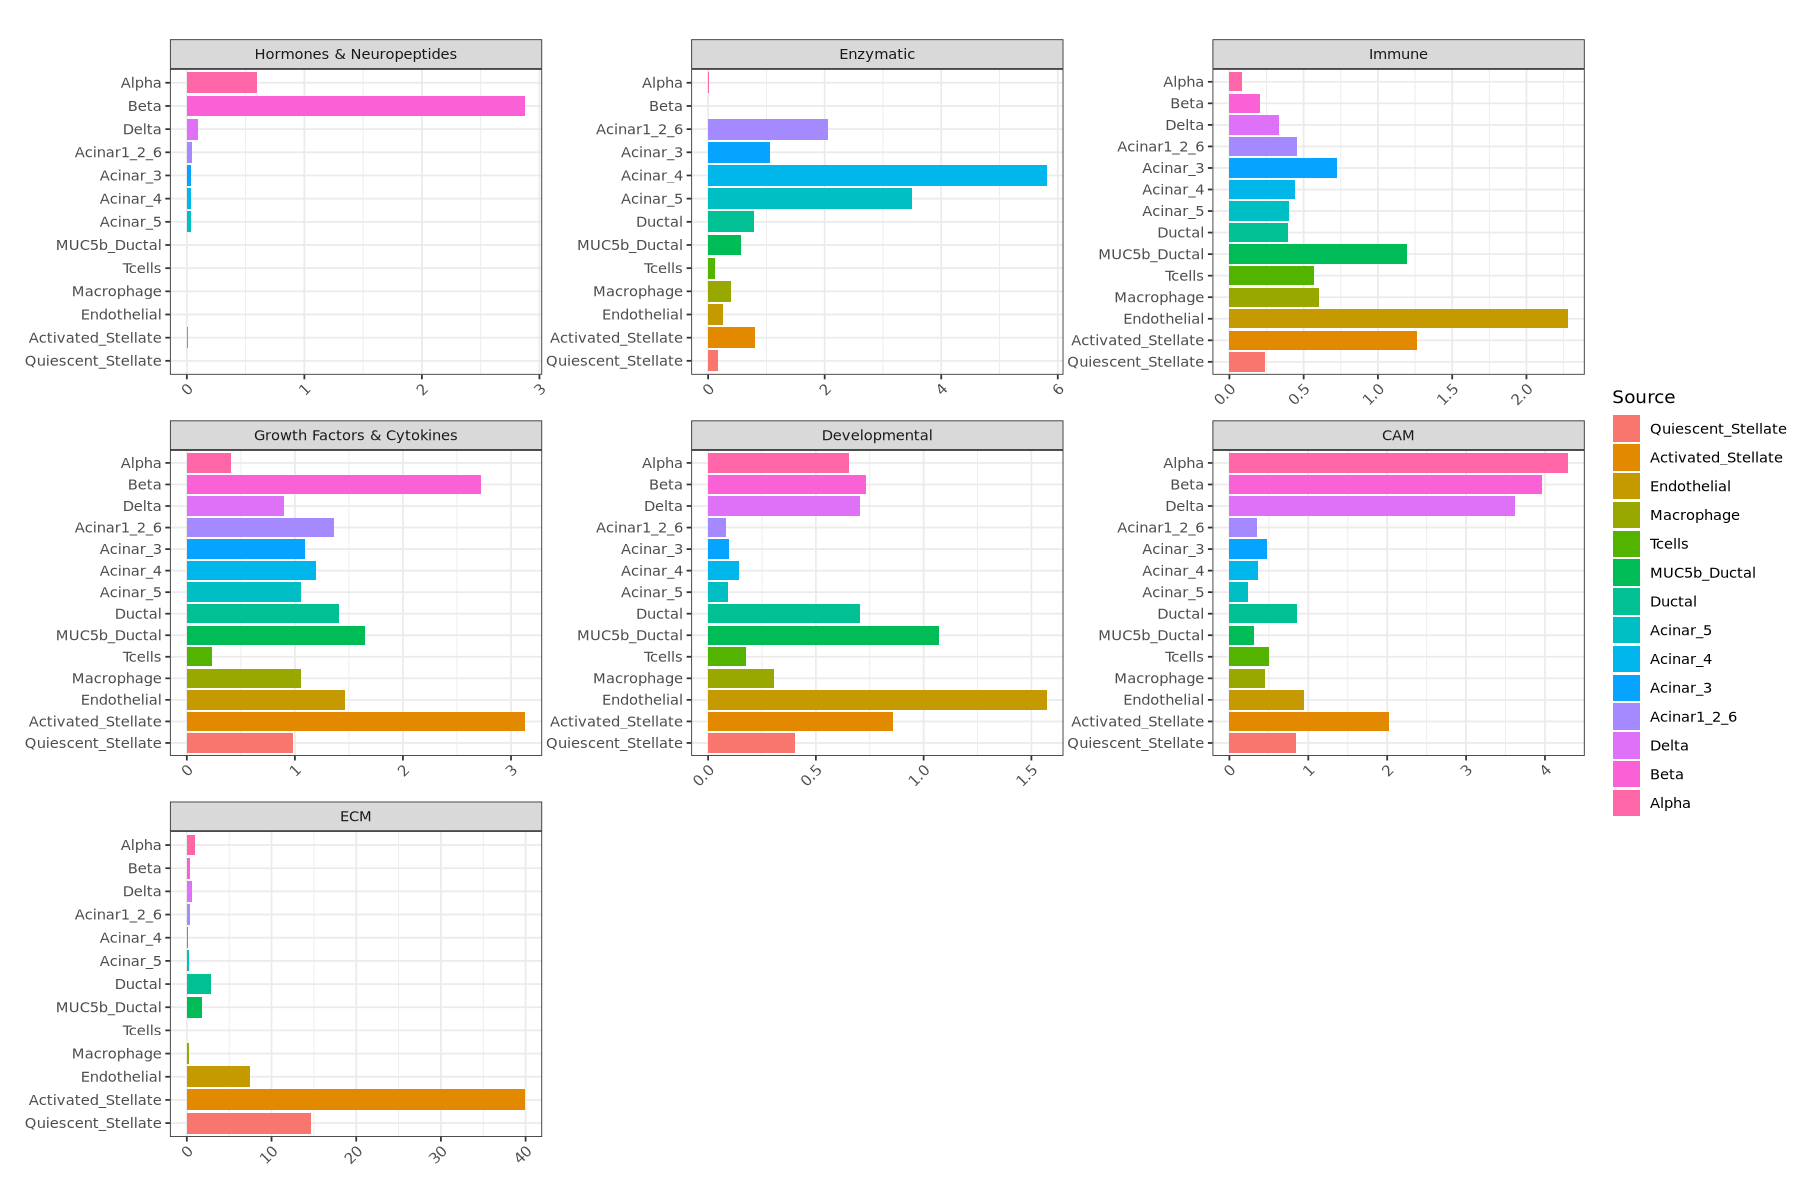

In [15]:
options(repr.plot.width=15, repr.plot.height=10)
gg1 = ggplot(aggregated_data, aes(x = prob, y = source, fill = source)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  facet_wrap(~ Signaling, scales = "free") +
  theme_bw() +
  labs(x = "",
       y = "",
       fill = "Source",
       title = "") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
gg1

In [16]:
file = paste(permutations.test.res.dir, "OutgoingSignaling_bycategory.pdf", sep = "")
ggsave(file, gg1,
       width = 15, height = 10, 
       device = "pdf")

In [17]:
permutations.test.res.dir

[1] "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/Results/corrected.permutation.test/Results/"

In [309]:
# Perform the aggregation
aggregated_data <- aggregate(prob ~ Signaling + source + compartment.source, LR.data.consensus.sig.thresh, sum)
# normalize by condition size and linear transformation
aggregated_data <- aggregated_data %>%
  dplyr::mutate(interaction.ID = as.character(paste(source, Signaling, sep = "--"))) %>%
  dplyr::group_by(Signaling) %>%
  dplyr::mutate(prob.fraction = scale(prob)) %>%
  dplyr::ungroup()

aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = rev(unique(compartment)))
aggregated_data$source = factor(aggregated_data$source, levels = rev.cell.pop.order)
# remove signaling we don't need
aggregated_data = dplyr::filter(aggregated_data, 
                                !Signaling %in% c("Other"))
aggregated_data$Signaling = factor(aggregated_data$Signaling, 
                                  levels = c("Hormones & Neuropeptides", "Enzymatic", 
                                            "Immune", "Growth Factors & Cytokines", "Developmental",
                                            "CAM", "ECM"))

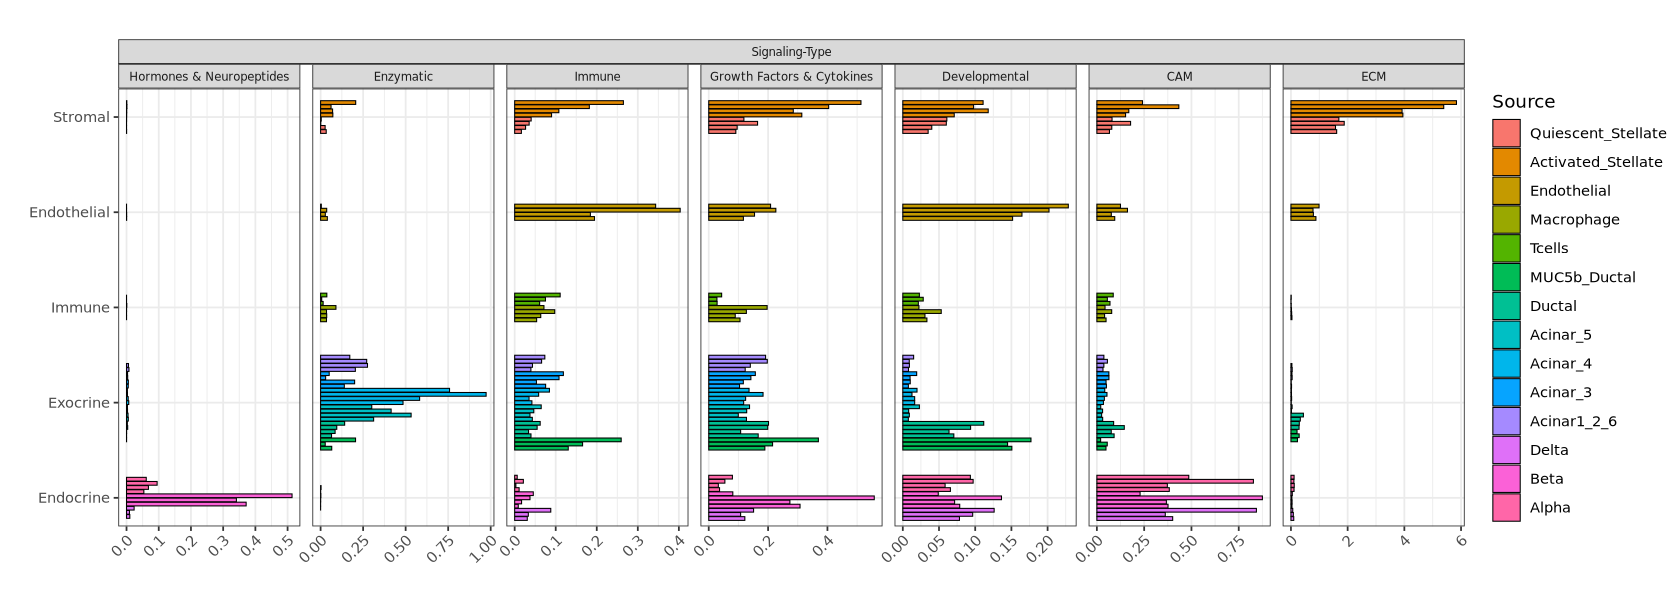

In [375]:
options(repr.plot.width=14, repr.plot.height=5)
ggplot(aggregated_data, aes(x = prob.norm, y = compartment.source, fill = source)) +
  geom_bar(stat = "identity", position = position_dodge2(preserve = "single"),
           color = "black", linewidth = 0.3, width = 1) +
  theme_bw() +
  labs(x = "",
       y = "",
       fill = "Source",
       title = "") +
  scale_y_discrete(expand = expansion(add = c(0.3, 0.3)))+
  theme(axis.text.x = element_text(angle = 45, hjust = 1),
        strip.text.x = element_text(size = 7),
        strip.text.y = element_text(size = 12),
        panel.spacing = unit(0.5, "lines")) +
  facet_nested(cols = vars("Signaling-Type", Signaling),
               scales = "free", space = "fixed")